In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [ ]:
dataset_path = "/content/drive/MyDrive/Ann and DeepLearning/Dataset"

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(48,48),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 13990 images belonging to 2 classes.


In [ ]:
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(48,48),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 3496 images belonging to 2 classes.


In [ ]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(48,48,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       409,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 429,121 (1.64 MB)

 Trainable params: 429,121 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2293s 5s/step - accuracy: 0.6124 - loss: 0.6496 - val_accuracy: 0.8032 - val_loss: 0.4807
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 118s 270ms/step - accuracy: 0.8308 - loss: 0.3903 - val_accuracy: 0.9070 - val_loss: 0.2339
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 117s 268ms/step - accuracy: 0.9415 - loss: 0.1682 - val_accuracy: 0.9122 - val_loss: 0.2118
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 116s 265ms/step - accuracy: 0.9576 - loss: 0.1318 - val_accuracy: 0.8850 - val_loss: 0.3163
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 118s 269ms/step - accuracy: 0.9642 - loss: 0.1084 - val_accuracy: 0.8936 - val_loss: 0.2700
Epoch 6/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 119s 272ms/step - accuracy: 0.9683 - loss: 0.0996 - val_accuracy: 0.8836 - val_loss: 0.2786
Epoch 7/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 116s 264ms/step - accuracy: 0.9723 - loss: 0.0850 - val_accuracy: 0.8819 - val_loss: 0.3089
Epoch 8/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 116s 266ms/step - accuracy: 0.9759 - l

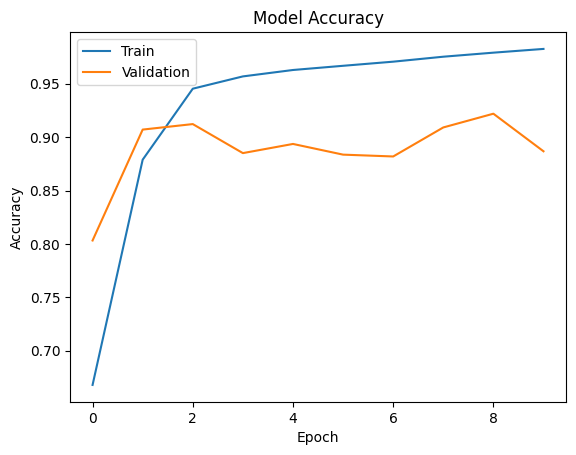

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

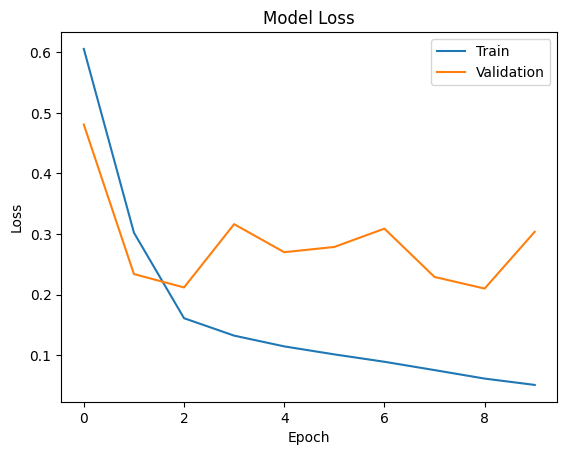

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [ ]:
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

110/110 ━━━━━━━━━━━━━━━━━━━━ 19s 177ms/step - accuracy: 0.8848 - loss: 0.3201
Validation Accuracy: 0.8867276906967163
Validation Loss: 0.30368393659591675


In [ ]:
model.save("/content/drive/MyDrive/malaria_model.h5")